# Predição do preço do ouro com XGBoost

Notebook do experimento XGBoost usando `data/processed/gold_features.csv`.

Ideia:
- usar as mesmas features do experimento GRU/CNN
- manter horizontes `5, 15, 30`
- manter alvo em log-retorno acumulado
- avaliar com as mesmas métricas e visualizações do `lib`

Como XGBoost espera entrada tabular 2D, cada janela de 60 dias é achatada em um vetor.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from src import (
    per_year_metrics,
    plot_predicted_vs_actual,
    plot_price_series,
    plot_residuals,
    plot_return_predictions,
    plot_scatter,
    plot_split_regions,
    plot_yearly_perf,
    regression_metrics,
    temporal_split,
)


from src import ROOT_DIR

REPO_ROOT = ROOT_DIR

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "xgboost não está instalado neste ambiente. Instale o pacote para executar este notebook."
    ) from exc

SEED = 42
LOOKBACK = 60
HORIZONS = [5, 15, 30]
GAP = max(HORIZONS)
CSV_PATH = REPO_ROOT / "data" / "processed" / "gold_features.csv"

np.random.seed(SEED)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10}
)

print("Repo root:", REPO_ROOT)

Repo root: /home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast


## Carregamento

In [2]:
def load_processed_data(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, sep=None, engine="python")
    df.columns = [c.strip().lower() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df = df.dropna(subset=["date", "close"]).sort_values("date").reset_index(drop=True)
    return df


def select_feature_cols(df: pd.DataFrame) -> list[str]:
    blocked = {"date", "close", "open", "high", "low"}
    return [
        col
        for col in df.columns
        if col not in blocked
        and not col.startswith("y_")
        and pd.api.types.is_numeric_dtype(df[col])
        and df[col].nunique(dropna=True) > 1
    ]


df = load_processed_data(CSV_PATH)
feature_cols = select_feature_cols(df)

print(f"{len(df)} linhas | {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"{len(feature_cols)} features")
print(feature_cols)
df.head()

6177 linhas | 2000-08-30 -> 2025-04-14
19 features
['volume', 'log_ret_1', 'log_ret_5', 'log_ret_21', 'vol_5', 'vol_21', 'vol_ratio', 'dist_ma20', 'dist_ma50', 'ma_cross', 'rsi', 'macd_hist', 'boll_b', 'drawdown_252', 'hl_range', 'close_pos', 'gap_open', 'fear_ratio', 'fear_ma5']


,date,close,volume,log_ret_1,log_ret_5,log_ret_21,vol_5,vol_21,vol_ratio,dist_ma20,...,boll_b,drawdown_252,hl_range,close_pos,gap_open,fear_ratio,fear_ma5,y_5,y_15,y_30
0,2000-08-30,273.9,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,NaN,0.000000,NaN,0.000365,-0.013231,0.009086
1,2000-08-31,278.3,0,0.015937,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.012576,0.5,0.003280,0.000000,NaN,-0.018130,-0.023633,-0.021428
2,2000-09-01,277.0,0,-0.004682,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,-0.004682,0.062500,NaN,-0.014179,-0.010525,-0.020055
3,2000-09-05,275.8,2,-0.004342,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,-0.004342,0.111111,NaN,-0.010571,-0.006913,-0.017188
4,2000-09-06,274.2,0,-0.005818,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,-0.005818,0.142857,0.063294,-0.005119,0.015201,-0.014325


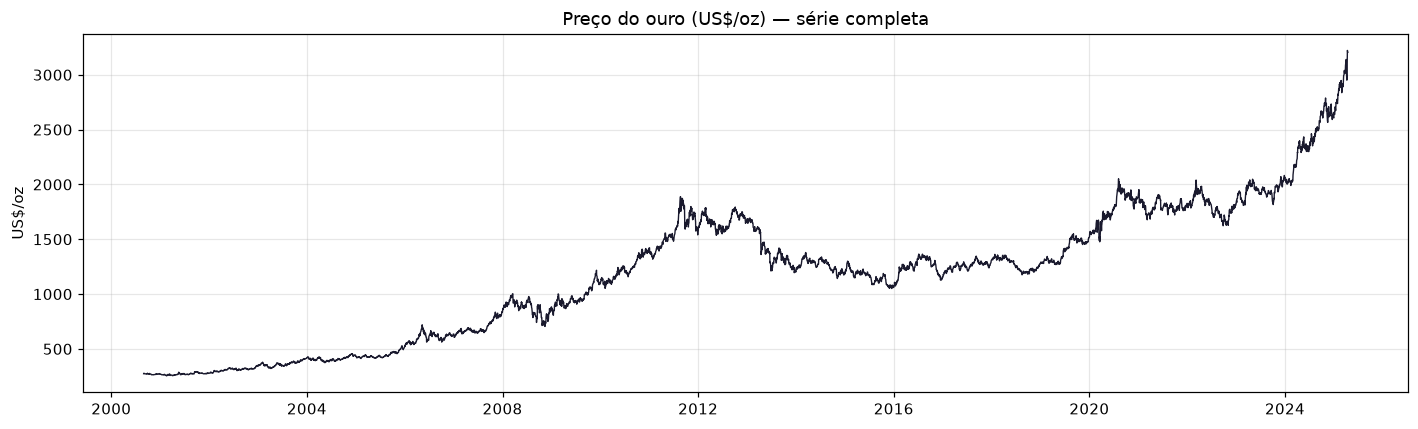

In [3]:
fig = plot_price_series(
    df["date"],
    df["close"],
    title="Preço do ouro (US$/oz) — série completa",
    ylabel="US$/oz",
)
plt.show()

## Split temporal e janelas

In [4]:
splits = temporal_split(
    df=df,
    feature_cols=feature_cols,
    horizons=HORIZONS,
    lookback=LOOKBACK,
    gap=GAP,
)

for name, ws in splits.items():
    d0 = df["date"].iloc[ws.idx[0]].date()
    d1 = df["date"].iloc[ws.idx[-1]].date()
    print(f"{name:>6}: {ws.X.shape} | {d0} -> {d1}")

treino: (4013, 60, 19) | 2001-11-29 -> 2017-11-27
   val: (837, 60, 19) | 2018-04-11 -> 2021-08-05
 teste: (807, 60, 19) | 2021-12-14 -> 2025-03-03


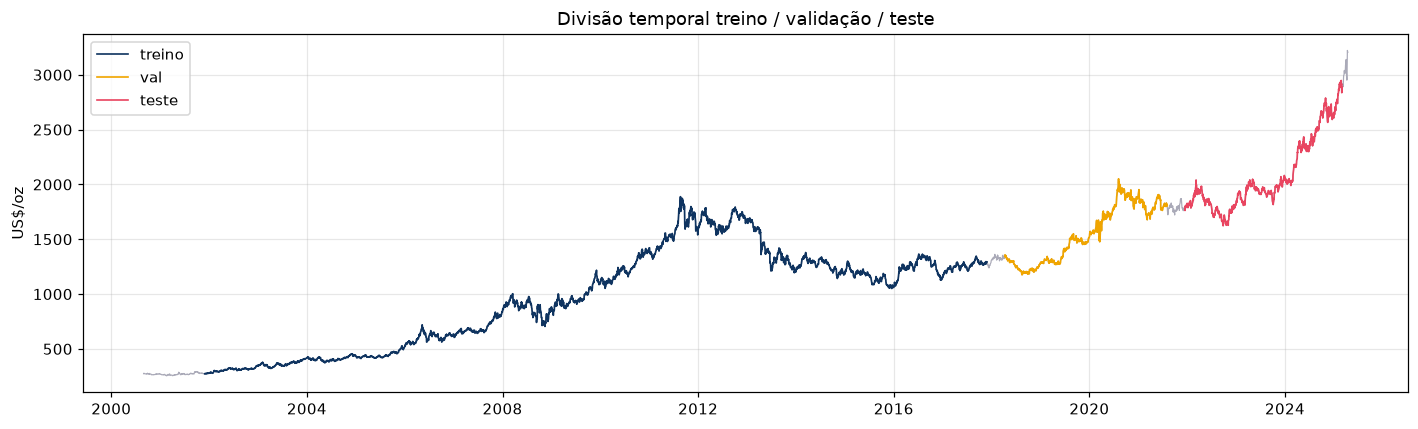

In [5]:
fig = plot_split_regions(
    df,
    {name: (ws.X, ws.Y, ws.prices, ws.idx) for name, ws in splits.items()},
    title="Divisão temporal treino / validação / teste",
    ylabel="US$/oz",
)
plt.show()

## Flatten das janelas para XGBoost

In [6]:
def flatten_windows(X: np.ndarray) -> np.ndarray:
    return X.reshape(X.shape[0], -1).astype(np.float32)


def make_window_feature_names(feature_cols: list[str], lookback: int) -> list[str]:
    names = []
    for lag in range(lookback - 1, -1, -1):
        for col in feature_cols:
            names.append(f"{col}_t-{lag}")
    return names


X = {name: flatten_windows(ws.X) for name, ws in splits.items()}
Y = {name: ws.Y.astype(np.float32) for name, ws in splits.items()}
Prices = {name: ws.prices for name, ws in splits.items()}
Idx = {name: ws.idx for name, ws in splits.items()}
window_feature_names = make_window_feature_names(feature_cols, LOOKBACK)

print("X treino:", X["treino"].shape)
print("Y treino:", Y["treino"].shape)
print("n window features:", len(window_feature_names))

X treino: (4013, 1140)
Y treino: (4013, 3)
n window features: 1140


## Modelo XGBoost

## Melhores parâmetros (BayesSearchCV)

Parâmetros obtidos via busca bayesiana com validação cruzada temporal (`TimeSeriesSplit`, `n_splits=5`).
Métrica otimizada: `neg_mean_squared_error`.

| Parâmetro | h=5 | h=15 | h=30 |
|---|---|---|---|
| `colsample_bytree` | 0.8390 | 0.7736 | 0.7667 |
| `gamma` | 0.1721 | 0.5000 | 0.5000 |
| `learning_rate` | 0.02368 | 0.02319 | 0.02000 |
| `max_depth` | 4 | 5 | 5 |
| `min_child_weight` | 3 | 3 | 3 |
| `n_estimators` | 336 | 308 | 463 |
| `reg_alpha` | 8.56e-06 | 0.05925 | 1.0 |
| `reg_lambda` | 1.8918 | 2.2792 | 0.2395 |
| `subsample` | 0.8615 | 0.9426 | 0.7500 |
| **CV score (neg MSE)** | **-0.00066** | **-0.001854** | **-0.003419** |


In [7]:
import xgboost as xgb

BEST_PARAMS = {
    5: {
        "colsample_bytree": 0.8389665024602303,
        "gamma": 0.17209652192016012,
        "learning_rate": 0.023676821618006886,
        "max_depth": 4,
        "min_child_weight": 3,
        "n_estimators": 336,
        "reg_alpha": 8.564230042602063e-06,
        "reg_lambda": 1.8917563805150739,
        "subsample": 0.8614680846067603,
    },
    15: {
        "colsample_bytree": 0.7736202652488748,
        "gamma": 0.49999999999999994,
        "learning_rate": 0.02318915192718661,
        "max_depth": 5,
        "min_child_weight": 3,
        "n_estimators": 308,
        "reg_alpha": 0.05925102923200062,
        "reg_lambda": 2.2791571711710703,
        "subsample": 0.942565902567476,
    },
    30: {
        "colsample_bytree": 0.7667094432406032,
        "gamma": 0.49999999999999994,
        "learning_rate": 0.020000000000000004,
        "max_depth": 5,
        "min_child_weight": 3,
        "n_estimators": 463,
        "reg_alpha": 1.0,
        "reg_lambda": 0.2395239871791339,
        "subsample": 0.75,
    },
}


def build_model(horizon: int) -> xgb.XGBRegressor:
    params = BEST_PARAMS[horizon]
    return xgb.XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        device="cpu",
        random_state=SEED,
        n_jobs=-1,
        **params,
    )


models = {}
preds = {}

for j, h in enumerate(HORIZONS):
    model = build_model(h)
    model.fit(
        X["treino"],
        Y["treino"][:, j],
        eval_set=[(X["val"], Y["val"][:, j])],
        verbose=False,
    )
    models[h] = model

for split in ["treino", "val", "teste"]:
    cols = [models[h].predict(X[split]) for h in HORIZONS]
    preds[split] = np.column_stack(cols).astype(np.float32)

print("modelos treinados:", list(models))

modelos treinados: [5, 15, 30]


## Avaliação

In [8]:
tbl = pd.concat(
    [
        regression_metrics(
            Y[split],
            preds[split],
            Prices[split],
            HORIZONS,
            split_name=split,
        )
        for split in ["treino", "val", "teste"]
    ],
    ignore_index=True,
)
tbl.round(3)

,split,h,MAE,RMSE,MAPE%,DirAcc%,MAE/naive
0,treino,5,18.771,27.167,1.949,55.096,0.996
1,treino,15,32.753,46.435,3.368,56.691,0.996
2,treino,30,45.264,63.484,4.597,57.787,1.004
3,val,5,24.335,36.005,1.516,57.109,0.989
4,val,15,40.518,55.178,2.525,53.047,1.001
5,val,30,59.725,74.026,3.733,53.883,1.017
6,teste,5,32.533,41.619,1.562,56.506,0.987
7,teste,15,58.258,73.110,2.779,58.860,0.974
8,teste,30,83.156,101.450,3.892,61.958,0.951


In [9]:
t = tbl[tbl["split"] == "teste"].set_index("h")[
    ["MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]
]
print("DESEMPENHO NO TESTE")
print(t.round(2).to_string())
print("\nMAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção")

DESEMPENHO NO TESTE
      MAE    RMSE  MAPE%  DirAcc%  MAE/naive
h                                           
5   32.53   41.62   1.56    56.51       0.99
15  58.26   73.11   2.78    58.86       0.97
30  83.16  101.45   3.89    61.96       0.95

MAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção


## Plots de desempenho

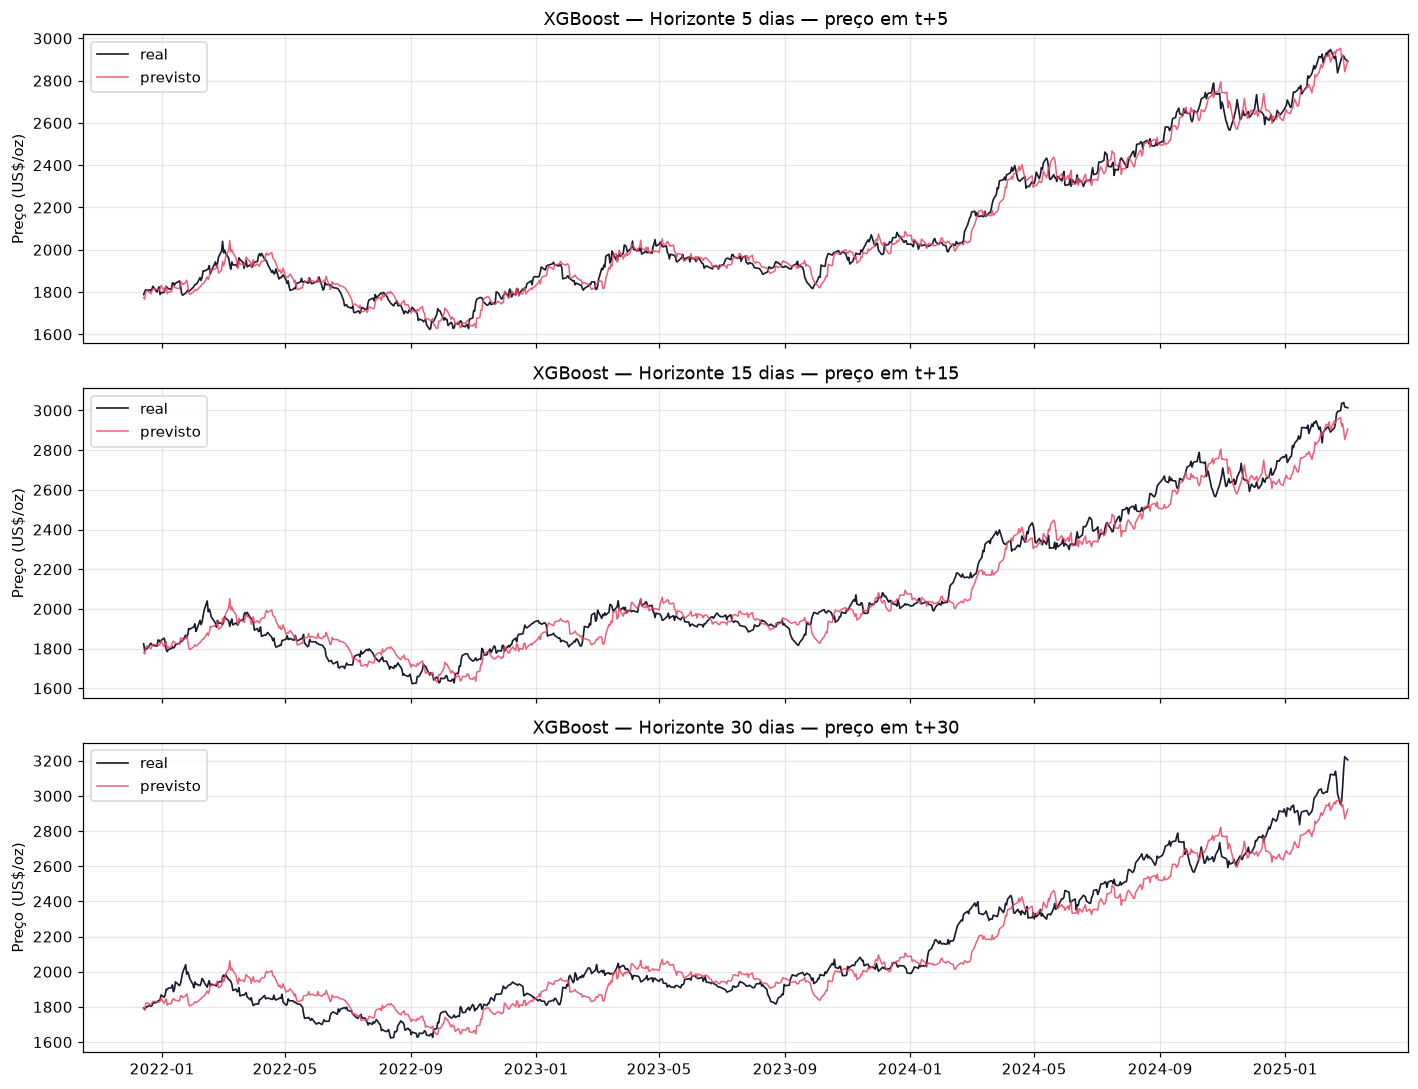

In [10]:
dates_te = df["date"].values[Idx["teste"]]
fig = plot_predicted_vs_actual(
    dates_te,
    Y["teste"],
    preds["teste"],
    Prices["teste"],
    HORIZONS,
    ylabel="Preço (US$/oz)",
    model_name="XGBoost",
)
plt.show()

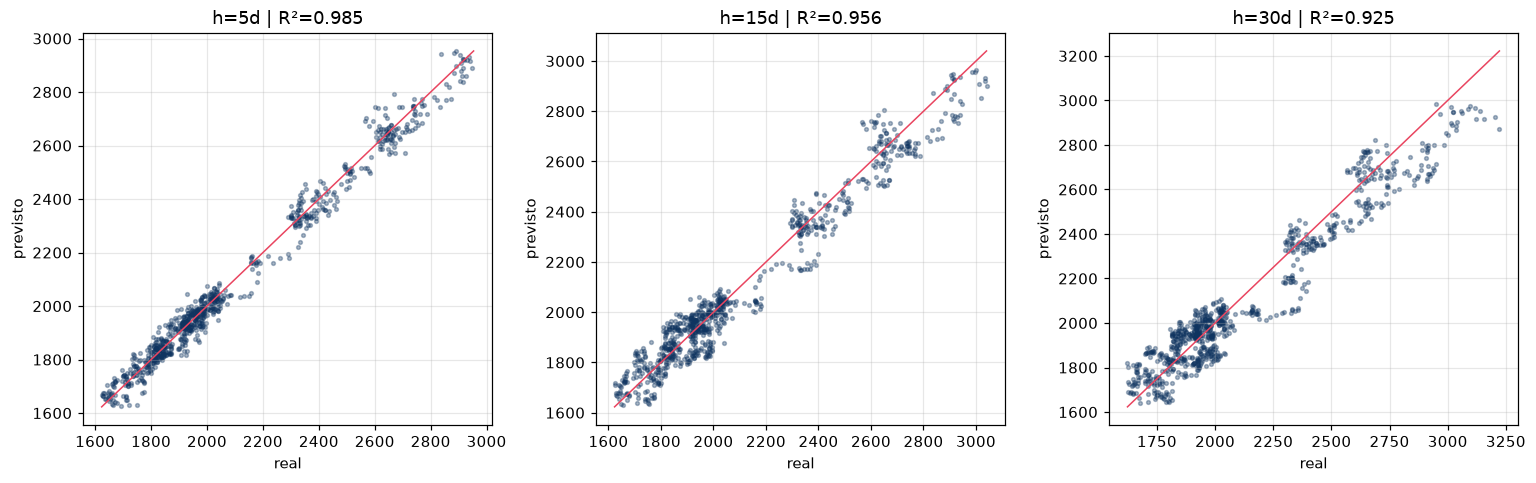

In [11]:
fig = plot_scatter(
    Y["teste"],
    preds["teste"],
    Prices["teste"],
    HORIZONS,
)
plt.show()

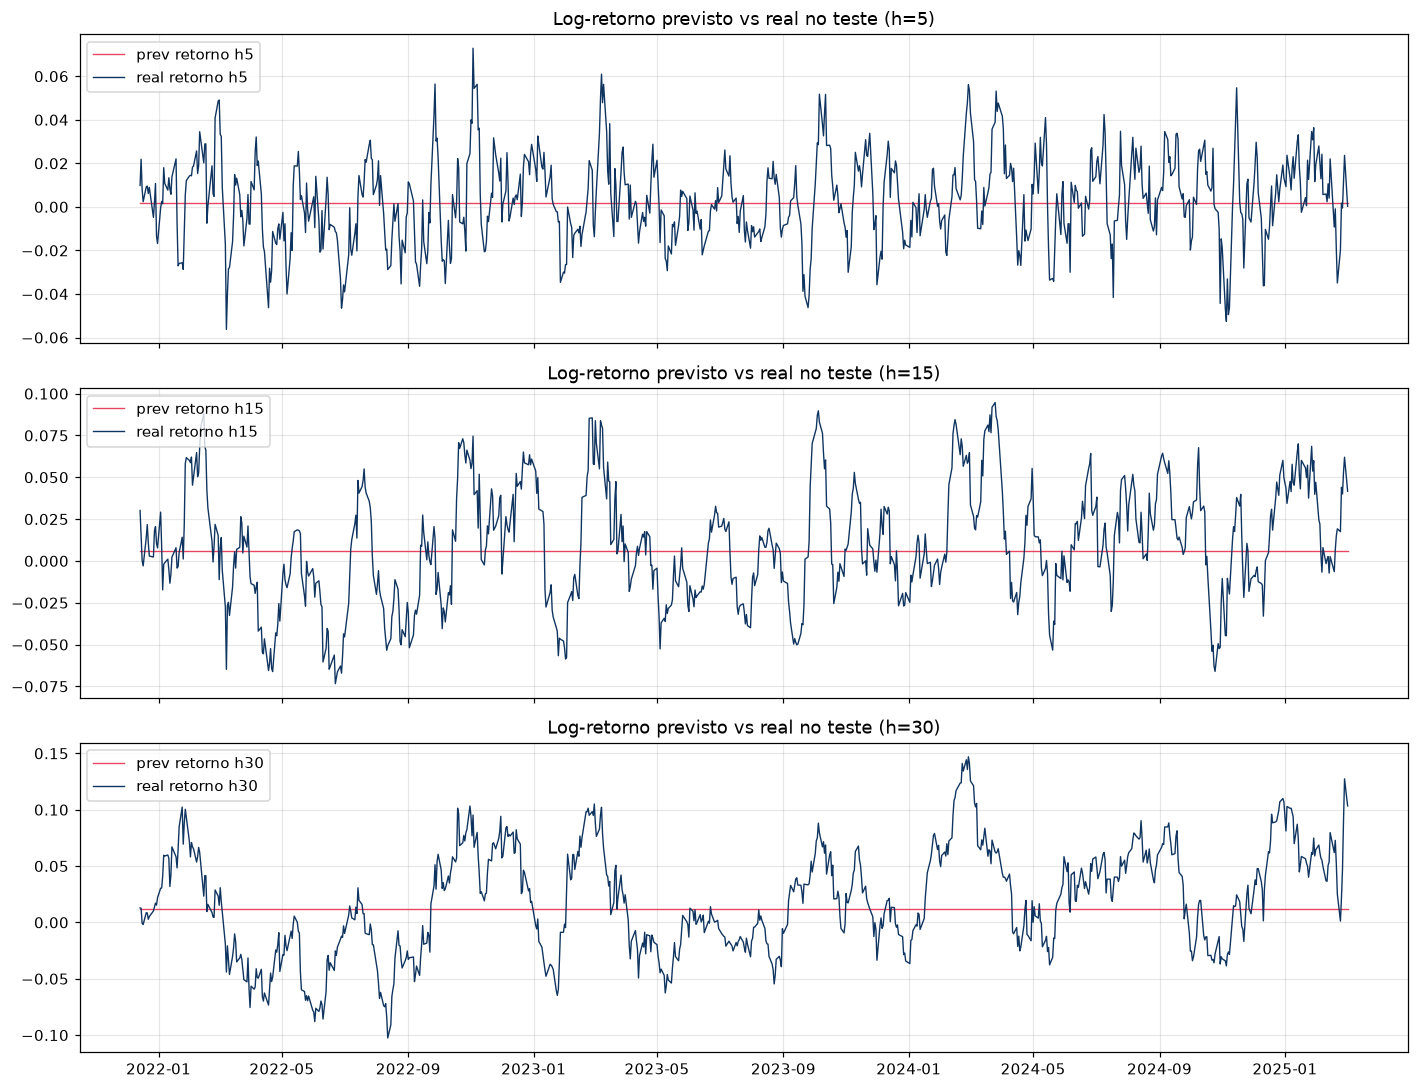

In [12]:
fig = plot_return_predictions(
    dates_te,
    Y["teste"],
    preds["teste"],
    HORIZONS,
)
plt.show()

Distribuição dos log-retornos previstos e reais (teste)

h=5d
  Real  — mean: +0.00302  std: 0.01974  min: -0.05626  max: +0.07287
  Pred  — mean: +0.00191  std: 0.00000  min: +0.00191  max: +0.00191
  Ratio std pred/real: 0.0000  (1.0 = escala perfeita)

h=15d
  Real  — mean: +0.00929  std: 0.03454  min: -0.07339  max: +0.09469
  Pred  — mean: +0.00567  std: 0.00000  min: +0.00567  max: +0.00567
  Ratio std pred/real: 0.0000  (1.0 = escala perfeita)

h=30d
  Real  — mean: +0.01904  std: 0.04646  min: -0.10255  max: +0.14694
  Pred  — mean: +0.01149  std: 0.00000  min: +0.01149  max: +0.01149
  Ratio std pred/real: 0.0000  (1.0 = escala perfeita)


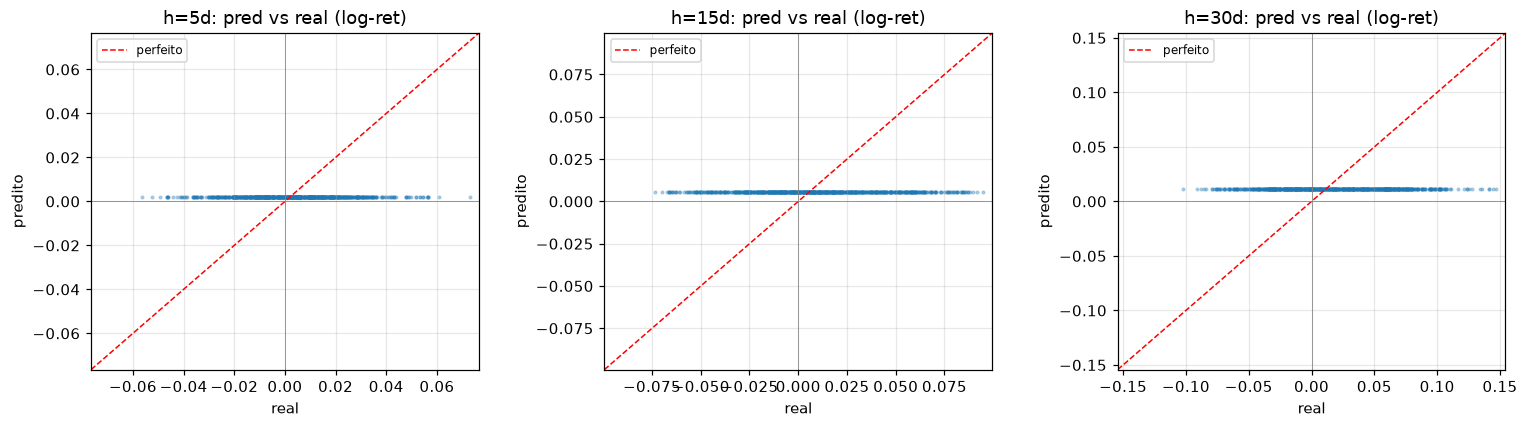

In [13]:
# Diagnóstico: distribuição das predições vs real
print("=" * 60)
print("Distribuição dos log-retornos previstos e reais (teste)")
print("=" * 60)
for j, h in enumerate(HORIZONS):
    y_real = Y["teste"][:, j]
    y_pred = preds["teste"][:, j]
    print(f"\nh={h}d")
    print(f"  Real  — mean: {y_real.mean():+.5f}  std: {y_real.std():.5f}  min: {y_real.min():+.5f}  max: {y_real.max():+.5f}")
    print(f"  Pred  — mean: {y_pred.mean():+.5f}  std: {y_pred.std():.5f}  min: {y_pred.min():+.5f}  max: {y_pred.max():+.5f}")
    print(f"  Ratio std pred/real: {y_pred.std() / y_real.std():.4f}  (1.0 = escala perfeita)")

# Scatter predito vs real por horizonte
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(14, 4))
for ax, (j, h) in zip(axes, enumerate(HORIZONS)):
    y_real = Y["teste"][:, j]
    y_pred = preds["teste"][:, j]
    ax.scatter(y_real, y_pred, s=3, alpha=0.3)
    lim = max(abs(y_real).max(), abs(y_pred).max()) * 1.05
    ax.axline((0, 0), slope=1, color="red", lw=1, ls="--", label="perfeito")
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title(f"h={h}d: pred vs real (log-ret)")
    ax.set_xlabel("real")
    ax.set_ylabel("predito")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
h30_idx = HORIZONS.index(30)
yearly = per_year_metrics(
    Y["teste"],
    preds["teste"],
    Prices["teste"],
    dates_te,
    horizon_idx=h30_idx,
)
yearly

,DirAcc%,MAE/naive
ano,,
2021,84.615385,0.555428
2022,50.199203,1.016922
2023,50.800000,1.050996
2024,77.380952,0.885521
2025,100.000000,0.833559


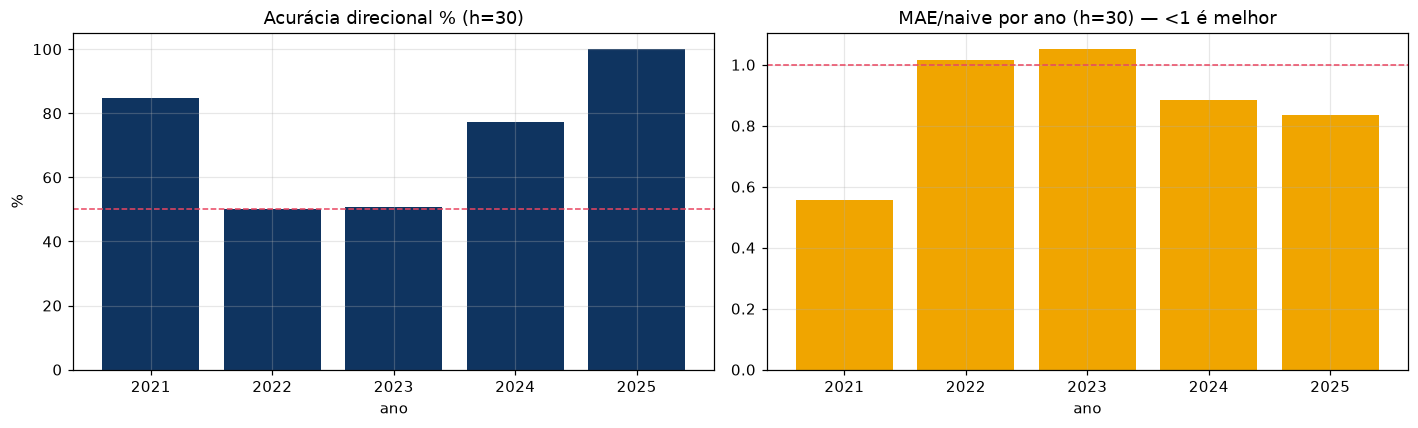

In [15]:
fig = plot_yearly_perf(yearly, horizon=30)
plt.show()

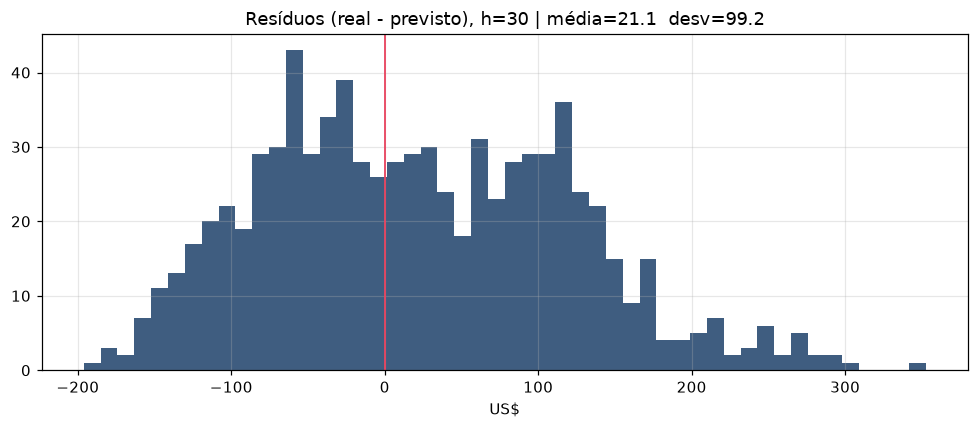

In [16]:
fig = plot_residuals(
    Y["teste"],
    preds["teste"],
    Prices["teste"],
    horizon_idx=h30_idx,
    horizon=30,
)
plt.show()

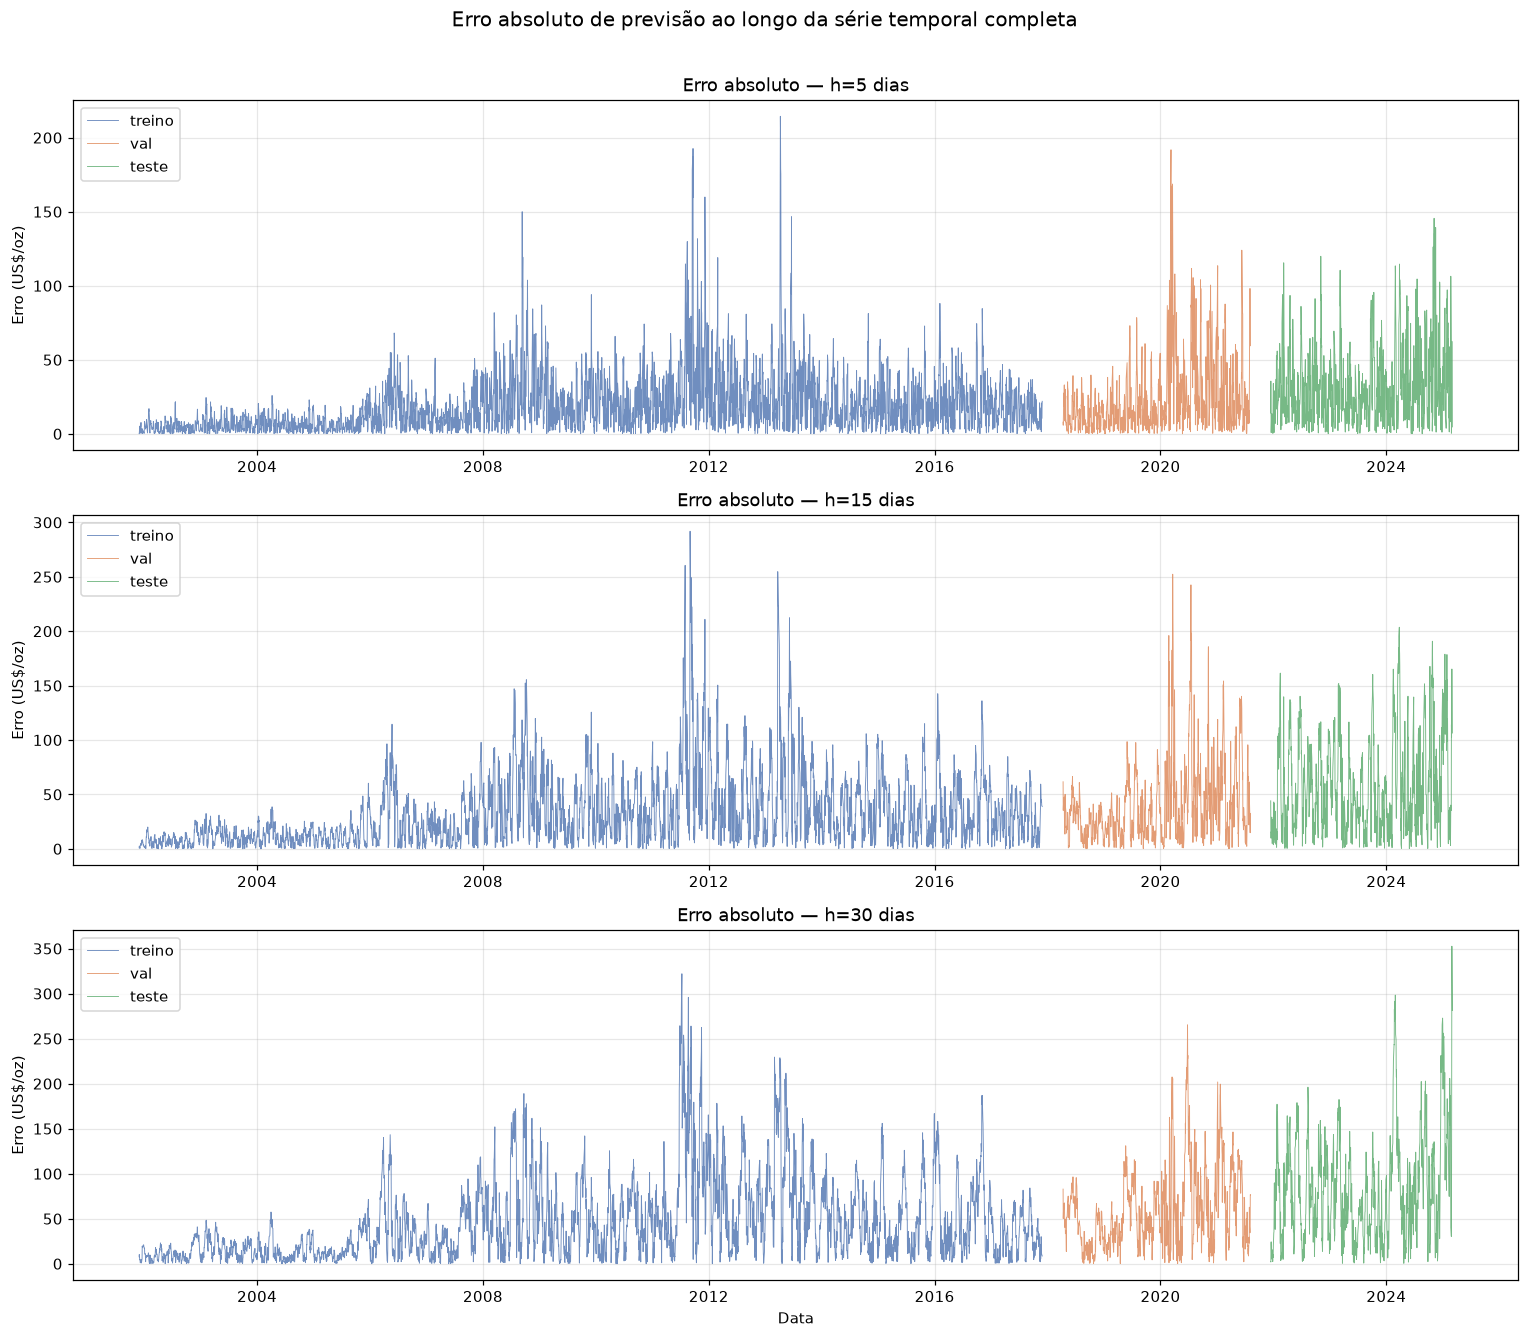

In [17]:
# Erro absoluto ao longo de toda a série temporal (treino + val + teste)
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(14, 4 * len(HORIZONS)), sharex=False)

colors = {"treino": "#4C72B0", "val": "#DD8452", "teste": "#55A868"}

for ax, (j, h) in zip(axes, enumerate(HORIZONS)):
    for split in ["treino", "val", "teste"]:
        dates_split = df["date"].values[Idx[split]]
        p_true = Prices[split] * np.exp(Y[split][:, j])
        p_pred = Prices[split] * np.exp(preds[split][:, j])
        abs_err = np.abs(p_true - p_pred)
        ax.plot(dates_split, abs_err, lw=0.6, alpha=0.8, label=split, color=colors[split])

    ax.set_title(f"Erro absoluto — h={h} dias")
    ax.set_ylabel("Erro (US$/oz)")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Data")
fig.suptitle("Erro absoluto de previsão ao longo da série temporal completa", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Importância de features

In [18]:
imp = pd.DataFrame(
    {f"h{h}": models[h].feature_importances_ for h in HORIZONS},
    index=window_feature_names,
)
imp["mean"] = imp.mean(axis=1)
top_imp = imp[imp["mean"] > 0].sort_values("mean", ascending=False).head(20)
top_imp

,h5,h15,h30,mean


In [19]:
if top_imp.empty:
    print("Nenhuma feature com importância > 0.")
else:
    fig, ax = plt.subplots(figsize=(10, max(5, len(top_imp) * 0.4)))
    top_imp["mean"].sort_values().plot(kind="barh", ax=ax)
    ax.set_title("Top features por importância média (gain)")
    ax.set_xlabel("feature importance (gain)")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.4f}"))
    plt.tight_layout()
    plt.show()

Nenhuma feature com importância > 0.


In [20]:
METRICS_DIR = REPO_ROOT / "outputs" / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
tbl.assign(model="xgboost").to_csv(METRICS_DIR / "metrics_xgboost.csv", index=False)
print(f"Métricas salvas em: {METRICS_DIR / 'metrics_xgboost.csv'}")

Métricas salvas em: /home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast/outputs/metrics/metrics_xgboost.csv
